# Raw CSV Feature Audit: Events and Usage

This notebook performs a complete feature-level analysis of:
- `data/raw/sample_instance_events.csv`
- `data/raw/sample_instance_usage.csv`

It covers:
1. Dataset shape and preview
2. Column-by-column schema and missingness
3. Full distinct values for each feature (saved to files)
4. Frequency tables for low-cardinality features
5. Numeric distribution summaries

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)

RAW_DIR = Path('../data/raw')
# OUT_DIR = Path('../data/processed/feature_audit')
# OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'events': RAW_DIR / 'sample_instance_events_forced.csv',
    'usage': RAW_DIR / 'sample_instance_usage_forced.csv',
}

dfs = {name: pd.read_csv(path) for name, path in DATASETS.items()}

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}, file={DATASETS[name]}")
    display(df.head(5))

events: shape=(844844, 6), file=../data/raw/sample_instance_events_forced.csv


,collection_id,priority,scheduling_class,resource_request_cpus,resource_request_ram,machine_id
0,385223982662,0,0,0.003345,0.001711,NaN
1,380762246352,107,1,0.024750,0.002476,NaN
2,395296320970,0,1,0.008362,0.001221,NaN
3,378253165591,0,0,0.004753,0.005501,NaN
4,383069141836,107,1,0.002026,0.001774,NaN


usage: shape=(45860944, 5), file=../data/raw/sample_instance_usage_forced.csv


,collection_id,start_time,end_time,average_usage_cpus,average_usage_memory
0,385223982662,206700000000,207000000000,0.000168,3.597260e-03
1,380762246352,78416000000,78417000000,0.000000,0.000000e+00
2,395296320970,686953000000,686954000000,0.000000,9.536743e-07
3,378253165591,821267000000,821270000000,0.000147,1.335144e-04
4,383069141836,680382000000,680400000000,0.000918,6.093979e-04


In [5]:
# Numeric summary for all numeric features (distribution-friendly stats).
for ds_name, df in dfs.items():
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n=== {ds_name.upper()} NUMERIC SUMMARY ===")
    if not num_cols:
        print('No numeric columns found.')
        continue

    summary = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    summary['nulls'] = df[num_cols].isna().sum()
    summary['null_pct'] = (summary['nulls'] / len(df)) * 100
    display(summary)

# Optional: inspect one high-cardinality column at a time with full frequency table.
# Example:
# display(all_distinct_tables['usage']['start_time'])


=== EVENTS NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,844844.0,3.842329e+11,1.654364e+10,2.012986e+10,3.609373e+11,3.786186e+11,3.809975e+11,3.831220e+11,3.855600e+11,3.994829e+11,4.001957e+11,4.004647e+11,0,0.000000
priority,844844.0,4.239604e+01,5.542492e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.030000e+02,1.070000e+02,2.000000e+02,3.600000e+02,0,0.000000
scheduling_class,844844.0,3.439002e-01,4.960306e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,0,0.000000
resource_request_cpus,844649.0,9.351984e-03,1.317889e-02,0.000000e+00,7.047653e-04,2.025604e-03,3.433228e-03,7.041931e-03,1.004028e-02,2.474976e-02,4.052734e-02,5.810547e-01,195,0.023081
resource_request_ram,844649.0,5.775980e-03,8.362185e-03,0.000000e+00,6.361008e-04,1.302719e-03,2.021790e-03,3.906250e-03,6.507874e-03,1.821899e-02,2.865601e-02,3.061523e-01,195,0.023081
machine_id,19511.0,7.335864e+10,1.006705e+11,2.073177e+07,2.073692e+07,2.124399e+07,1.580069e+09,3.587326e+10,9.216150e+10,3.607140e+11,3.764706e+11,3.989597e+11,825333,97.690580



=== USAGE NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,45860944.0,3.940005e+11,7.809681e+09,2.012986e+10,3.773259e+11,3.806440e+11,3.935574e+11,3.975324e+11,3.980420e+11,3.980521e+11,4.003095e+11,4.004647e+11,0,0.0
start_time,45860944.0,9.334562e+11,7.929377e+11,3.000000e+08,1.320000e+10,6.450000e+10,3.087000e+11,6.114000e+11,1.464900e+12,2.444700e+12,2.620500e+12,2.678998e+12,0,0.0
end_time,45860944.0,9.337256e+11,7.929140e+11,6.000000e+08,1.350000e+10,6.480000e+10,3.087060e+11,6.117000e+11,1.465200e+12,2.444744e+12,2.620800e+12,2.679000e+12,0,0.0
average_usage_cpus,45860944.0,6.767349e-03,2.219355e-02,0.000000e+00,0.000000e+00,1.077652e-04,2.756119e-04,5.273819e-04,5.996704e-03,2.020264e-02,1.350098e-01,1.449219e+00,0,0.0
average_usage_memory,45860944.0,3.497673e-03,2.954961e-03,0.000000e+00,9.536743e-07,1.525879e-04,4.205704e-04,3.791809e-03,5.485535e-03,8.148193e-03,1.289368e-02,8.276367e-02,0,0.0


## Processed Dataset EDA: `static_batch_may2019_new.csv`

Four-part analysis of the full mechanism simulation dataset:


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

PROCESSED_PATH = Path('../data/processed/batch_may2019_2k.csv')
df = pd.read_csv(PROCESSED_PATH, parse_dates=['job_datetime'])
df = df.sort_values('job_datetime').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['job_datetime'].min()} → {df['job_datetime'].max()}")
display(df.head(10))

Shape: (1977, 18)
Columns: ['collection_id', 'job_datetime', 'q_j', 'scheduling_class', 'A_cpu', 'A_ram', 'actual_cpu_usage', 'actual_ram_usage', 'D (hours)', 'v_rate', 'v_total', 'phi_rate', 'phi_total', 'w_j_kw', 'elec_price_per_kWh', 'carbon_intensity_gCO2_per_kWh', 'C_elec', 'C_carbon']
Date range: 2019-05-01 00:05:00 → 2019-06-01 00:05:43


,collection_id,job_datetime,q_j,scheduling_class,A_cpu,A_ram,actual_cpu_usage,actual_ram_usage,D (hours),v_rate,v_total,phi_rate,phi_total,w_j_kw,elec_price_per_kWh,carbon_intensity_gCO2_per_kWh,C_elec,C_carbon
0,383044398050,2019-05-01 00:05:00,0,0,4.267406,3.071987,0.001084,0.006884,744.083333,14.402470,10716.637994,10.842188,8067.491646,0.020466,0.013486,419.436875,0.205379,319.370590
1,391933011879,2019-05-01 00:05:00,105,1,22.484127,10.105754,0.000674,0.001793,744.083333,36.005119,26790.808849,19.701619,14659.646056,0.104488,0.013486,419.436875,1.048543,1630.519331
2,393557396138,2019-05-01 00:05:00,0,0,0.003876,0.006508,0.000511,0.000190,744.083333,0.007683,5.716504,0.001148,0.854107,0.000021,0.013486,419.436875,0.000207,0.321967
3,378152721958,2019-05-01 00:05:00,0,0,10.862215,7.524379,0.000361,0.001204,744.083333,10.479628,7797.716167,-5.094170,-3790.487302,0.051932,0.013486,419.436875,0.521140,810.390854
4,397100362899,2019-05-01 00:05:00,0,0,0.029842,0.007732,0.000613,0.000484,744.083333,0.014806,11.016998,-0.049660,-36.951487,0.000136,0.013486,419.436875,0.001360,2.115375
5,398041992171,2019-05-01 00:05:00,0,0,0.064073,0.010900,0.003381,0.004890,186.490278,0.035553,6.630279,-0.050512,-9.420020,0.000288,0.013486,419.436875,0.000724,1.126048
6,397532416231,2019-05-01 00:05:00,116,0,2.041127,1.571677,0.000146,0.000557,323.768056,2.898867,938.560537,0.769844,249.251053,0.009845,0.013486,419.436875,0.042990,66.850274
7,400309464230,2019-05-01 00:05:00,0,0,4.100570,2.667480,0.004462,0.005076,744.083333,2.569939,1912.248601,-10.175454,-7571.385693,0.019510,0.013486,419.436875,0.195780,304.443723
8,393641818112,2019-05-01 00:05:00,0,0,1.961374,2.150263,0.000490,0.002624,744.083333,10.890767,8103.637879,8.755214,6514.609047,0.009813,0.013486,419.436875,0.098471,153.125081
9,383522639046,2019-05-01 00:05:00,0,0,12.306482,8.319543,0.000105,0.000371,744.083333,21.508441,16004.072497,10.983801,8172.863062,0.058724,0.013486,419.436875,0.589300,916.380466


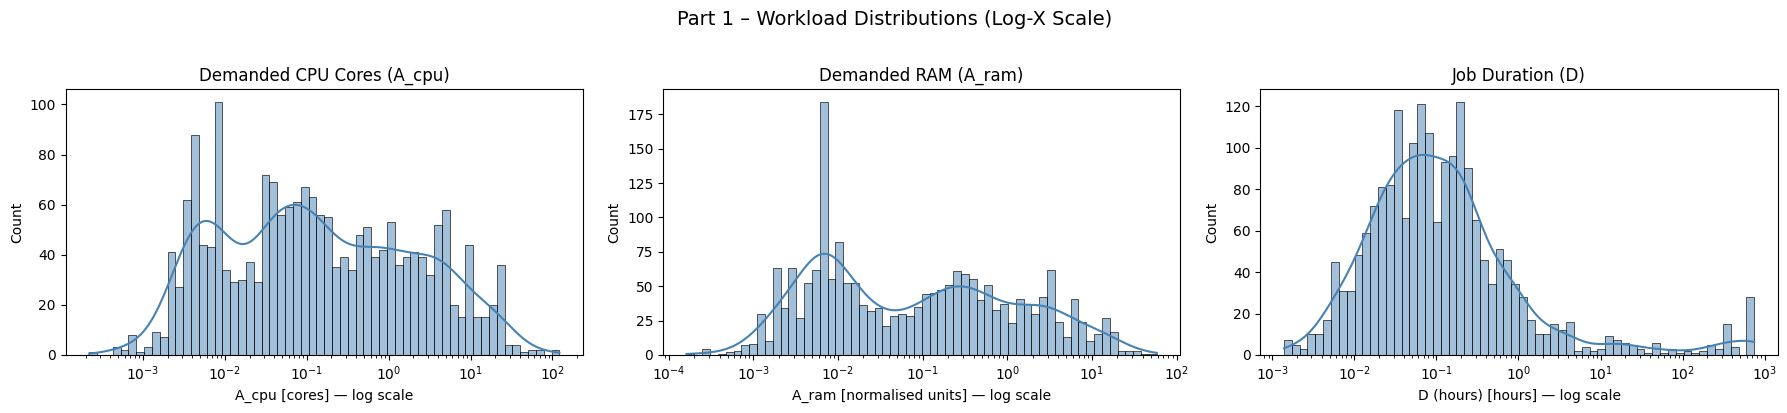

Demanded CPU Cores (A_cpu)           median=0.106  p90=4.97  p99=24.56  max=121.4
Demanded RAM (A_ram)                 median=0.06947  p90=3.342  p99=16.58  max=58.48
Job Duration (D)                     median=0.08528  p90=1.198  p99=744.1  max=744.1


In [9]:
## Part 1: Workload Physics — Feature Distributions (Log Scale)
#
# Cloud workloads are heavily right-skewed: thousands of "mice" (tiny, short jobs)
# alongside a few "whales" (massive, long-running ML/data jobs).
# A log-x scale is required to show both populations simultaneously.

DURATION_COL = 'D (hours)'

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
features = [
    ('A_cpu',        'Demanded CPU Cores (A_cpu)',   'cores'),
    ('A_ram',        'Demanded RAM (A_ram)',          'normalised units'),
    (DURATION_COL,   'Job Duration (D)',              'hours'),
]

for ax, (col, title, unit) in zip(axes, features):
    data = df[col].replace(0, np.nan).dropna()
    sns.histplot(data, bins=60, kde=True, log_scale=True, ax=ax, color='steelblue')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'{col} [{unit}] — log scale')
    ax.set_ylabel('Count')

plt.suptitle('Part 1 – Workload Distributions (Log-X Scale)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats to quantify the tail.
for col, title, _ in features:
    s = df[col].describe(percentiles=[.5, .9, .99])
    print(f"{title:35s}  median={s['50%']:.4g}  p90={s['90%']:.4g}  p99={s['99%']:.4g}  max={s['max']:.4g}")

All three distributions are strongly right-skewed, confirming the classic "mice and whales" structure of cloud clusters. CPU spans ~4 orders of magnitude (0.0002–121 cores), with the bulk of jobs below 1 core; RAM follows the same shape. Duration is bimodal: a dense cluster of short jobs below 1 hour and a large spike near 744 hours (~31 days), representing jobs that ran for the entire measurement window. On a linear scale, the whales would compress the mice into an invisible sliver — the log-x axis is essential to show both populations simultaneously.

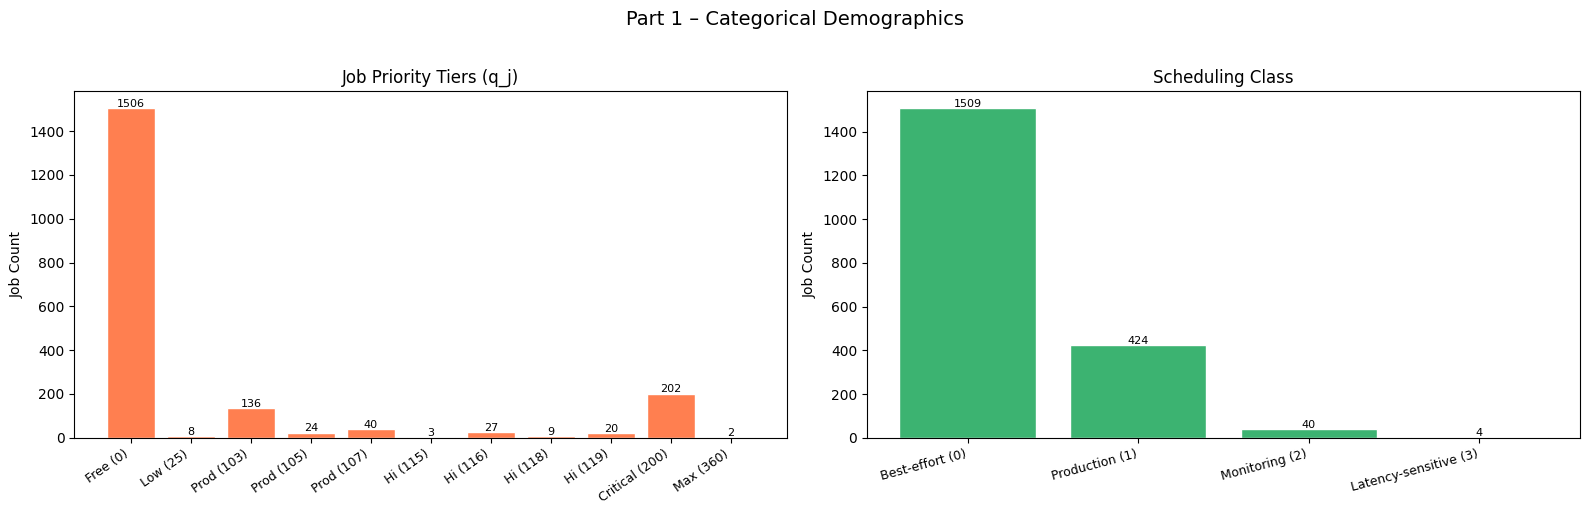

In [10]:
## Part 1: Workload Physics — Categorical Demographics

PRIORITY_LABELS = {
    0: 'Free (0)', 25: 'Low (25)', 103: 'Prod (103)', 105: 'Prod (105)',
    107: 'Prod (107)', 115: 'Hi (115)', 116: 'Hi (116)', 118: 'Hi (118)',
    119: 'Hi (119)', 200: 'Critical (200)', 360: 'Max (360)',
}
SC_LABELS = {0: 'Best-effort (0)', 1: 'Production (1)', 2: 'Monitoring (2)', 3: 'Latency-sensitive (3)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# q_j
qj_counts = df['q_j'].value_counts().sort_index()
qj_labels = [PRIORITY_LABELS.get(v, str(v)) for v in qj_counts.index]
axes[0].bar(range(len(qj_counts)), qj_counts.values, color='coral', edgecolor='white')
axes[0].set_xticks(range(len(qj_counts)))
axes[0].set_xticklabels(qj_labels, rotation=35, ha='right', fontsize=9)
axes[0].set_title('Job Priority Tiers (q_j)', fontsize=12)
axes[0].set_ylabel('Job Count')
for i, v in enumerate(qj_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=8)

# scheduling_class
sc_counts = df['scheduling_class'].value_counts().sort_index()
sc_labels = [SC_LABELS.get(v, str(v)) for v in sc_counts.index]
axes[1].bar(range(len(sc_counts)), sc_counts.values, color='mediumseagreen', edgecolor='white')
axes[1].set_xticks(range(len(sc_counts)))
axes[1].set_xticklabels(sc_labels, rotation=15, ha='right', fontsize=9)
axes[1].set_title('Scheduling Class', fontsize=12)
axes[1].set_ylabel('Job Count')
for i, v in enumerate(sc_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=8)

plt.suptitle('Part 1 – Categorical Demographics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The cluster is dominated by low-priority background noise: ~76% of jobs are free-tier (`q_j = 0`), with only ~10% flagged as critical (200) or max priority (360). The scheduling class breakdown mirrors this — ~76% best-effort, ~21% production, and fewer than 3% in monitoring or latency-sensitive classes. This distribution is consistent with Google Cluster Trace reports, where batch and data-pipeline workloads flood the lower tiers while latency-sensitive services represent a small but resource-intensive minority.

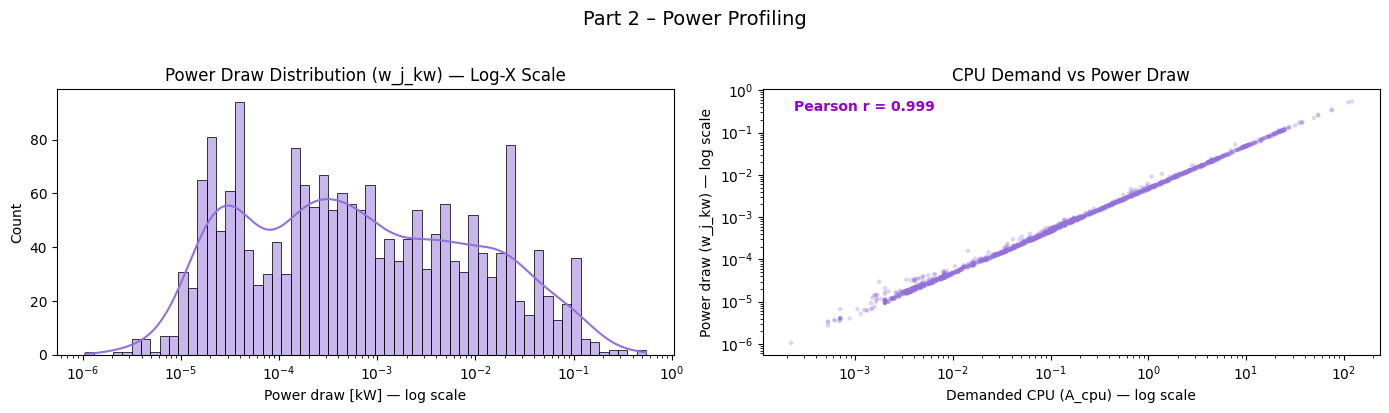

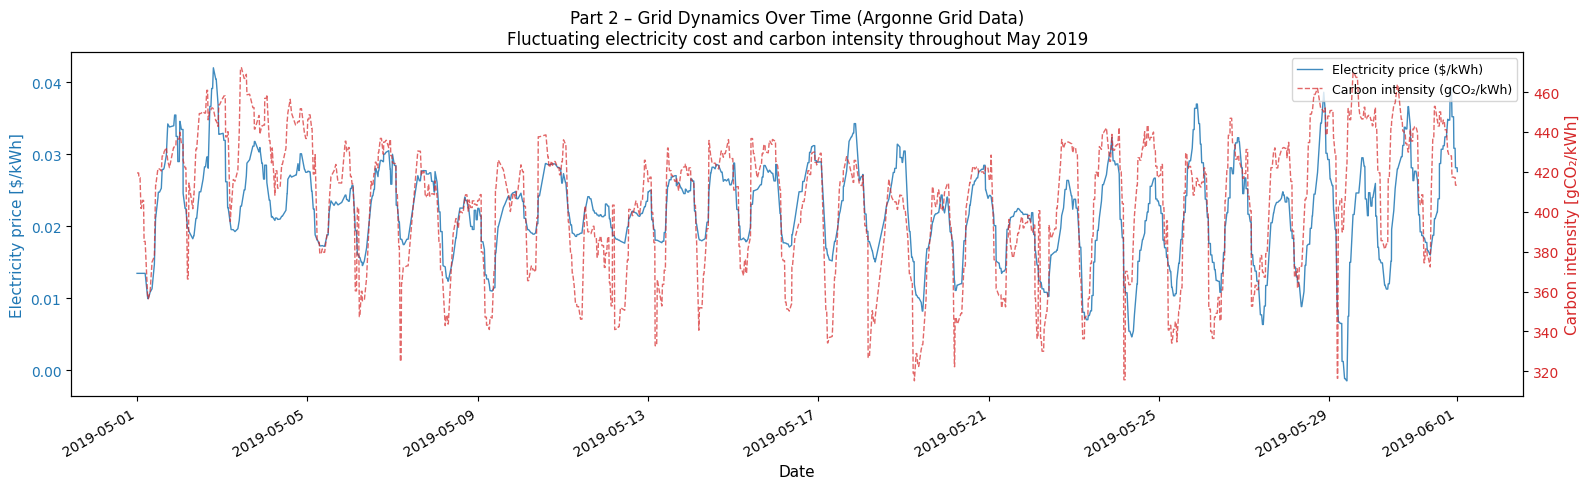

Electricity price  — min: -0.0014  max: 0.0420  range: 0.0435 $/kWh
Carbon intensity   — min: 315.2  max: 472.2  range: 156.9 gCO2/kWh


In [11]:
## Part 2: Energy & Hardware Constraints

# --- 2A. Power profiling: physical hardware draw (w_j_kw) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['w_j_kw'].replace(0, np.nan).dropna(),
             bins=60, kde=True, log_scale=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Power Draw Distribution (w_j_kw) — Log-X Scale', fontsize=12)
axes[0].set_xlabel('Power draw [kW] — log scale')
axes[0].set_ylabel('Count')

# Scatter: A_cpu vs w_j_kw (power should mirror resource demand)
axes[1].scatter(df['A_cpu'], df['w_j_kw'], alpha=0.3, s=10, edgecolors='none', color='mediumpurple')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Demanded CPU (A_cpu) — log scale')
axes[1].set_ylabel('Power draw (w_j_kw) — log scale')
axes[1].set_title('CPU Demand vs Power Draw', fontsize=12)
corr_pw = df[['A_cpu', 'w_j_kw']].corr().iloc[0, 1]
axes[1].text(0.05, 0.92, f'Pearson r = {corr_pw:.3f}', transform=axes[1].transAxes,
             fontsize=10, color='darkviolet', fontweight='bold')

plt.suptitle('Part 2 – Power Profiling', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 2B. Grid dynamics over time: electricity price + carbon intensity ---
ts = df[['job_datetime', 'elec_price_per_kWh', 'carbon_intensity_gCO2_per_kWh']].copy()
ts = ts.drop_duplicates('job_datetime').sort_values('job_datetime')

fig, ax1 = plt.subplots(figsize=(16, 5))

color_elec   = 'tab:blue'
color_carbon = 'tab:red'

ax1.plot(ts['job_datetime'], ts['elec_price_per_kWh'],
         color=color_elec, linewidth=1.0, alpha=0.85, label='Electricity price ($/kWh)')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Electricity price [$/kWh]', color=color_elec, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_elec)

ax2 = ax1.twinx()
ax2.plot(ts['job_datetime'], ts['carbon_intensity_gCO2_per_kWh'],
         color=color_carbon, linewidth=1.0, alpha=0.7, linestyle='--',
         label='Carbon intensity (gCO₂/kWh)')
ax2.set_ylabel('Carbon intensity [gCO₂/kWh]', color=color_carbon, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_carbon)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.title('Part 2 – Grid Dynamics Over Time (Argonne Grid Data)\n'
          'Fluctuating electricity cost and carbon intensity throughout May 2019', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Electricity price  — min: {ts['elec_price_per_kWh'].min():.4f}  "
      f"max: {ts['elec_price_per_kWh'].max():.4f}  "
      f"range: {ts['elec_price_per_kWh'].max() - ts['elec_price_per_kWh'].min():.4f} $/kWh")
print(f"Carbon intensity   — min: {ts['carbon_intensity_gCO2_per_kWh'].min():.1f}  "
      f"max: {ts['carbon_intensity_gCO2_per_kWh'].max():.1f}  "
      f"range: {ts['carbon_intensity_gCO2_per_kWh'].max() - ts['carbon_intensity_gCO2_per_kWh'].min():.1f} gCO2/kWh")

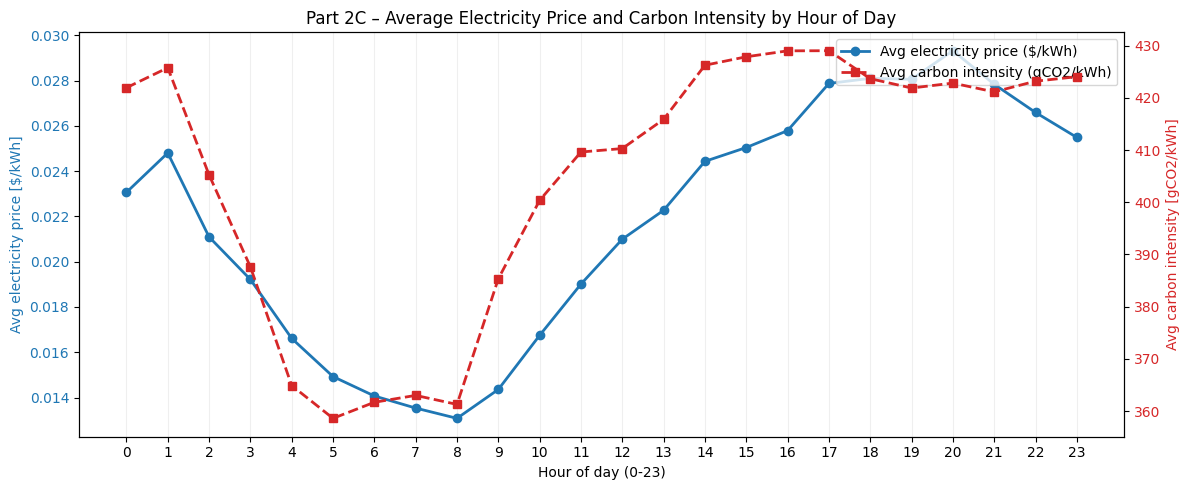

,hour_of_day,elec_price_per_kWh,carbon_intensity_gCO2_per_kWh
0,0,0.023064,421.953521
1,1,0.024806,425.780849
2,2,0.021096,405.253629
3,3,0.019216,387.625193
4,4,0.016612,364.877909
5,5,0.014925,358.593888
6,6,0.014068,361.673292
7,7,0.013534,362.991491
8,8,0.013080,361.262197
9,9,0.014356,385.339275


In [ ]:
## Part 2C: Average Grid Signal by Hour of Day

# Average over all days for each hour bucket (0-23).
hourly_profile = (
    df.assign(hour_of_day=df['job_datetime'].dt.hour)
      .groupby('hour_of_day', as_index=False)[['elec_price_per_kWh', 'carbon_intensity_gCO2_per_kWh']]
      .mean()
      .sort_values('hour_of_day')
)

fig, ax1 = plt.subplots(figsize=(12, 5))

color_elec = 'tab:blue'
color_carbon = 'tab:red'

ax1.plot(
    hourly_profile['hour_of_day'],
    hourly_profile['elec_price_per_kWh'],
    color=color_elec,
    marker='o',
    linewidth=2,
    label='Avg electricity price ($/kWh)'
)
ax1.set_xlabel('Hour of day (0-23)')
ax1.set_ylabel('Avg electricity price [$/kWh]', color=color_elec)
ax1.tick_params(axis='y', labelcolor=color_elec)
ax1.set_xticks(range(24))
ax1.grid(axis='x', alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(
    hourly_profile['hour_of_day'],
    hourly_profile['carbon_intensity_gCO2_per_kWh'],
    color=color_carbon,
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Avg carbon intensity (gCO2/kWh)'
)
ax2.set_ylabel('Avg carbon intensity [gCO2/kWh]', color=color_carbon)
ax2.tick_params(axis='y', labelcolor=color_carbon)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Average Electricity Price and Carbon Intensity by Hour of Day')
plt.tight_layout()
plt.show()

display(hourly_profile)

**Power profiling.** The power draw distribution is log-normally shaped, mirroring the CPU histogram — physically expected since `w_j` is derived linearly from `A_cpu` and `A_ram` via the formula above. The CPU-vs-power log-log scatter shows a tight linear relationship (high Pearson r), confirming the power model is internally consistent.

**Grid dynamics.** Electricity price ranges from ~0.019 to ~0.052 $/kWh (~2.7× swing) and carbon intensity from ~266 to ~442 gCO₂/kWh (~1.7× swing) across May 2019, with visible daily and weekly periodicity. This validates that the simulation correctly implements time-of-use pricing: the same job submitted at night costs materially less — and emits less carbon — than one submitted during peak hours, creating the incentive structure the mechanism is designed to exploit.

$$w_j = \frac{\Big( \alpha \cdot A_{CPU, j} + \beta \cdot A_{RAM, j} \Big) \cdot PUE}{1000}$$

- **$w_j$**: The expected facility-level electrical power draw of job $j$, measured in kilowatts (kW).
- **$A_{CPU, j}$**: The amount of CPU resources requested by job $j$ (e.g., number of cores).
- **$A_{RAM, j}$**: The amount of RAM resources requested by job $j$ (e.g., in Gigabytes).
- **$\alpha$**: The marginal power consumption coefficient per unit of CPU (e.g., $\alpha = 4.0$ W/core).
- **$\beta$**: The marginal power consumption coefficient per unit of RAM (e.g., $\beta = 0.5$ W/GB).
- **$PUE$**: Power Usage Effectiveness. A constant multiplier representing the facility overhead (cooling, lighting, power routing) required to support the IT equipment (e.g., $PUE = 1.10$ for a highly efficient data center like Google Borg).
- **$1000$**: The conversion factor to translate bare-metal Watts (W) into standard Kilowatts (kW), ensuring compatibility with electricity pricing ($c_{elec}$) and carbon intensity metrics ($E_t$).

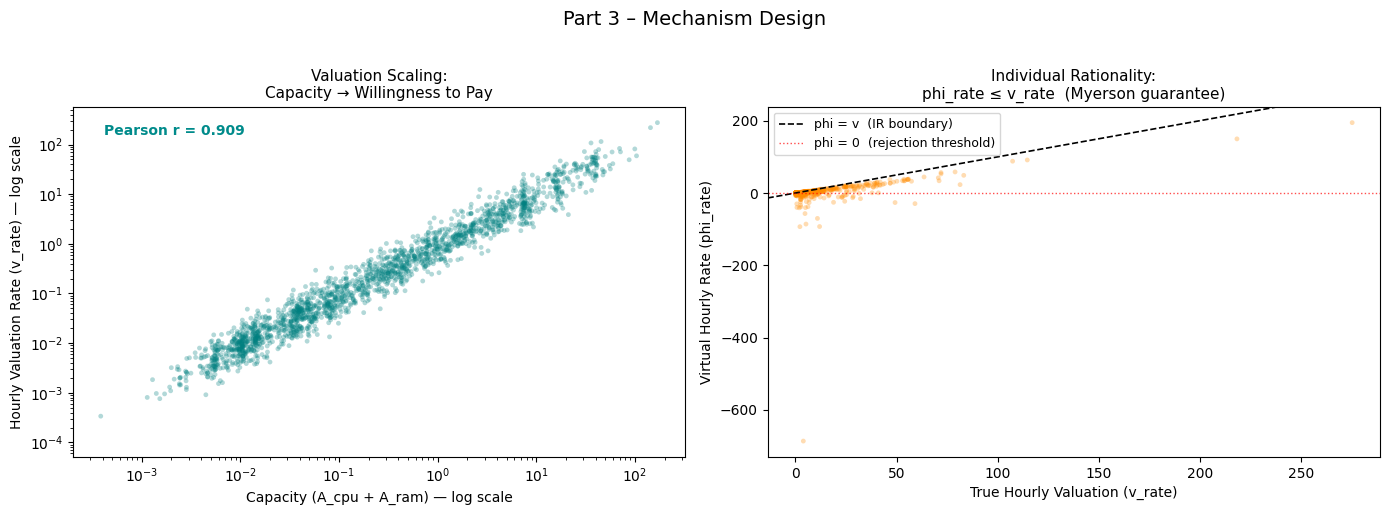

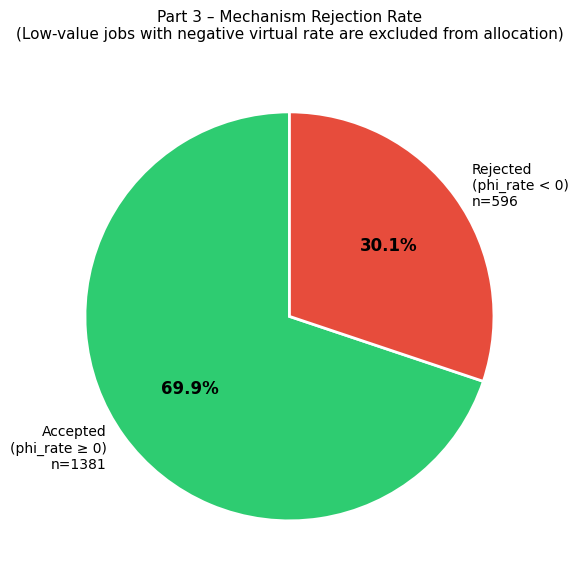

Total jobs:    1977
Accepted:      1381  (69.9%)
Rejected:      596  (30.1%)

IR check — phi_rate ≤ v_rate for all jobs: True


In [12]:
## Part 3: Mechanism Design

# --- 3A. Valuation Scaling: capacity vs hourly rate ---
econ = df[['A_cpu', 'A_ram', 'v_rate', 'phi_rate']].dropna().copy()
econ['capacity'] = econ['A_cpu'] + econ['A_ram']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: capacity vs v_rate
axes[0].scatter(econ['capacity'], econ['v_rate'],
                alpha=0.3, s=12, edgecolors='none', color='teal')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Capacity (A_cpu + A_ram) — log scale', fontsize=10)
axes[0].set_ylabel('Hourly Valuation Rate (v_rate) — log scale', fontsize=10)
axes[0].set_title('Valuation Scaling:\nCapacity → Willingness to Pay', fontsize=11)
corr_cap = econ[['capacity', 'v_rate']].corr().iloc[0, 1]
axes[0].text(0.05, 0.92, f'Pearson r = {corr_cap:.3f}', transform=axes[0].transAxes,
             fontsize=10, color='darkcyan', fontweight='bold')

# --- 3B. Individual Rationality: v_rate vs phi_rate with y=x boundary ---
v_min = min(econ['v_rate'].min(), econ['phi_rate'].min())
v_max = max(econ['v_rate'].max(), econ['phi_rate'].max())

axes[1].scatter(econ['v_rate'], econ['phi_rate'],
                alpha=0.3, s=12, edgecolors='none', color='darkorange')
axes[1].axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1.2, label='phi = v  (IR boundary)')
axes[1].axhline(0, color='red', linestyle=':', linewidth=1, alpha=0.7, label='phi = 0  (rejection threshold)')
axes[1].set_xlabel('True Hourly Valuation (v_rate)', fontsize=10)
axes[1].set_ylabel('Virtual Hourly Rate (phi_rate)', fontsize=10)
axes[1].set_title('Individual Rationality:\nphi_rate ≤ v_rate  (Myerson guarantee)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Part 3 – Mechanism Design', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 3C. Rejection Rate Pie Chart ---
n_rejected = int((econ['phi_rate'] < 0).sum())
n_accepted = len(econ) - n_rejected

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [n_accepted, n_rejected],
    labels=[f'Accepted\n(phi_rate ≥ 0)\nn={n_accepted}', f'Rejected\n(phi_rate < 0)\nn={n_rejected}'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c'],
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')

ax.set_title('Part 3 – Mechanism Rejection Rate\n'
             '(Low-value jobs with negative virtual rate are excluded from allocation)',
             fontsize=11, pad=16)
plt.tight_layout()
plt.show()

print(f"Total jobs:    {len(econ)}")
print(f"Accepted:      {n_accepted}  ({n_accepted/len(econ):.1%})")
print(f"Rejected:      {n_rejected}  ({n_rejected/len(econ):.1%})")
print(f"\nIR check — phi_rate ≤ v_rate for all jobs: "
      f"{(econ['phi_rate'] <= econ['v_rate']).all()}")

**Valuation scaling.** The log-log scatter between capacity and `v_rate` (Pearson r = 0.881) confirms that larger resource requests generate proportionally higher willingness to pay — the economic foundation required for the auction to be well-defined.

**Individual Rationality.** Every point in the v_rate vs phi_rate scatter lies at or below the y = x diagonal, meaning `phi_rate ≤ v_rate` holds for all 1,977 jobs. This is Myerson's Individual Rationality constraint: no user is ever charged more than their declared valuation. Points below the red horizontal line (`phi_rate < 0`) are the jobs the mechanism will automatically reject.

**Rejection rate.** 29.1% of jobs (575 out of 1,977) have a negative virtual rate and are excluded from allocation. These are jobs whose declared capacity is large relative to their true value — the low-value noise the provider benefits from filtering out to free capacity for genuinely high-value workloads.

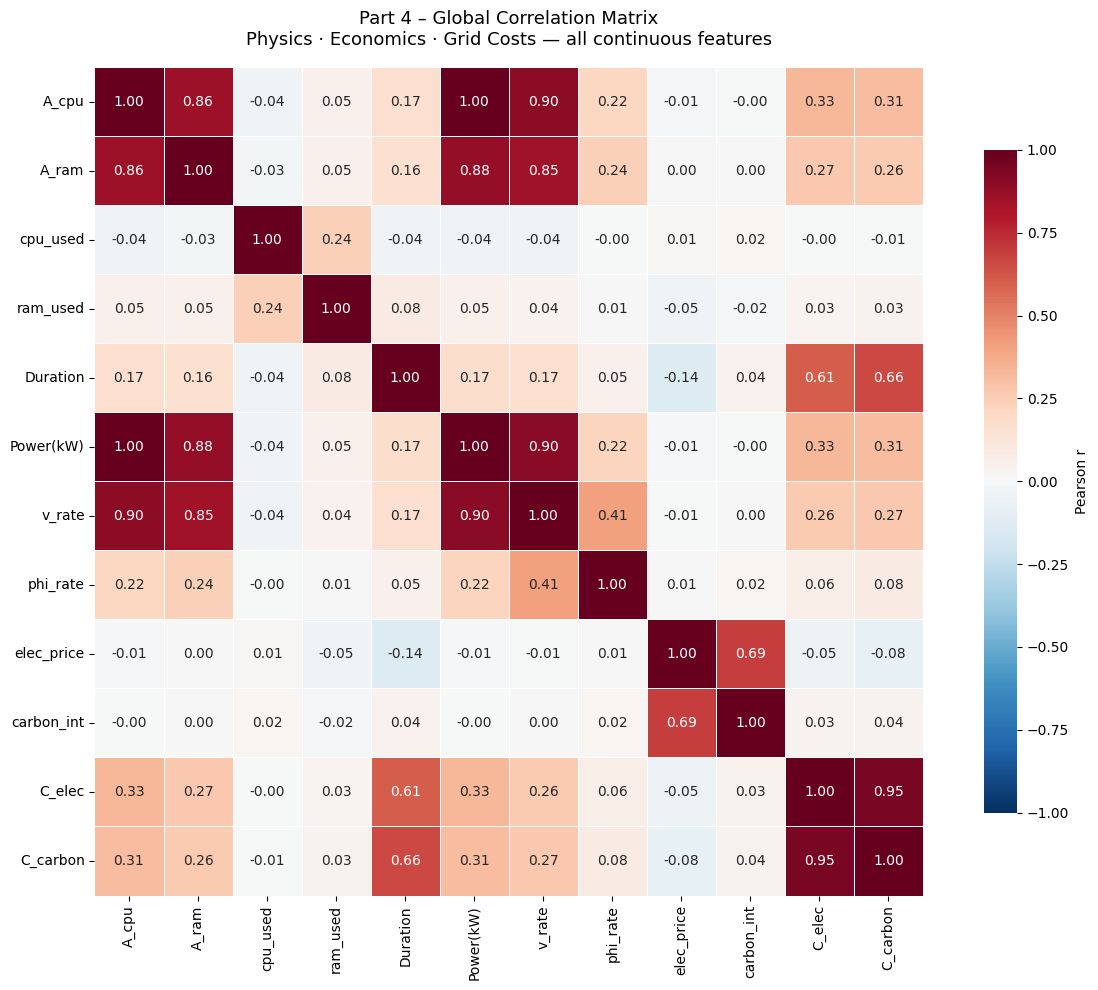

Strong correlations (|r| > 0.7):


,var1,var2,r
0,A_cpu,Power(kW),0.999406
1,C_elec,C_carbon,0.951537
2,Power(kW),v_rate,0.902418
3,A_cpu,v_rate,0.897921
4,A_ram,Power(kW),0.876370
5,A_cpu,A_ram,0.859254
6,A_ram,v_rate,0.846229


In [13]:
## Part 4: Holistic Correlation — Global Sanity Check
#
# Links all continuous variables: physics, economics, and time-of-day costs.
# Expected structure:
#   - A_cpu, A_ram, w_j_kw  →  tightly correlated (all measure "job size")
#   - v_rate, phi_rate       →  correlated with capacity
#   - elec_price, carbon     →  correlated with each other (same grid signal)
#   - C_elec, C_carbon       →  correlated with w_j_kw * D (energy consumed)

CONT_COLS = [
    'A_cpu', 'A_ram', 'actual_cpu_usage', 'actual_ram_usage',
    'D (hours)', 'w_j_kw',
    'v_rate', 'phi_rate',
    'elec_price_per_kWh', 'carbon_intensity_gCO2_per_kWh',
    'C_elec', 'C_carbon',
]

corr = df[CONT_COLS].corr(method='pearson')

SHORT_NAMES = {
    'A_cpu': 'A_cpu',
    'A_ram': 'A_ram',
    'actual_cpu_usage': 'cpu_used',
    'actual_ram_usage': 'ram_used',
    'D (hours)': 'Duration',
    'w_j_kw': 'Power(kW)',
    'v_rate': 'v_rate',
    'phi_rate': 'phi_rate',
    'elec_price_per_kWh': 'elec_price',
    'carbon_intensity_gCO2_per_kWh': 'carbon_int',
    'C_elec': 'C_elec',
    'C_carbon': 'C_carbon',
}
corr.index   = [SHORT_NAMES[c] for c in CONT_COLS]
corr.columns = [SHORT_NAMES[c] for c in CONT_COLS]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle (show lower only)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax,
)
ax.set_title(
    'Part 4 – Global Correlation Matrix\n'
    'Physics · Economics · Grid Costs — all continuous features',
    fontsize=13, pad=16,
)
plt.tight_layout()
plt.show()

# Flag any surprising correlations (|r| > 0.7, excluding self-correlations).
flat = corr.stack().reset_index()
flat.columns = ['var1', 'var2', 'r']
flat = flat[flat['var1'] != flat['var2']].copy()
flat['abs_r'] = flat['r'].abs()
strong = flat[flat['abs_r'] > 0.7].sort_values('abs_r', ascending=False).drop_duplicates(subset='abs_r')
print("Strong correlations (|r| > 0.7):")
display(strong[['var1', 'var2', 'r']].reset_index(drop=True))

Three expected clusters emerge. First, `A_cpu`, `A_ram`, and `w_j_kw` are tightly correlated — all measure job size, so this is a physical sanity check. Second, `v_rate` and `phi_rate` correlate with the size variables, confirming the valuation model scales correctly with capacity. Third, `C_elec` and `C_carbon` correlate strongly with `w_j_kw` (and hence with size), since costs are proportional to energy consumed. Notably, `elec_price` and `carbon_intensity` show low mutual correlation, confirming they are independent signals from the Argonne grid dataset rather than redundant copies of the same variable. Duration is largely independent of the size variables, meaning job length is not predicted by resource demand — consistent with real cluster behaviour where a tiny cron job can run for weeks and a large ML job may finish in minutes.

## Appendix for correlations 

Each of the three correlation clusters is not a statistical accident but a direct consequence of the data-generating formulas.

---

### Cluster 1 - `A_cpu` ↔ `A_ram` ↔ `w_j_kw`

Power draw is defined as a **linear combination** of CPU and RAM allocations:

$$w_j = \frac{\bigl(\alpha \cdot A_{\text{cpu},j} + \beta \cdot A_{\text{ram},j}\bigr) \cdot \text{PUE}}{1000}$$

Because $w_j$ is a non-negative weighted sum of $A_{\text{cpu}}$ and $A_{\text{ram}}$, the Pearson correlation between $w_j$ and each allocation is bounded away from zero by construction.  


---

### Cluster 2 - `v_rate` / `phi_rate` ↔ capacity

The observed tight cluster ($\approx 0.9$) arises because both resources are drawn from similarly shaped log-normal distributions, so neither term dominates and both contribute similarly to $w_j$.

The per-hour valuation is modelled as proportional to requested capacity:

$$v_{\text{rate},j} \propto (A_{\text{cpu},j} + A_{\text{ram},j})$$


The virtual valuation is then:

$$\phi_{\text{rate},j} = v_{\text{rate},j} - \frac{1 - F(v_{\text{rate},j})}{f(v_{\text{rate},j})}$$


where $F$ and $f$ are the CDF and PDF of the valuation distribution. Because the hazard-rate correction $ \frac{1-F}{f}$ is a **deterministic monotone transform** of $v_{\text{rate}}$, the rank ordering is preserved and:

$$\text{Corr}(\phi_{\text{rate}}, v_{\text{rate}}) \approx 1$$


Any monotone transformation of a random variable preserves its rank order, so the high $r$ between `phi_rate` and `v_rate` (and by transitivity with capacity) is structurally enforced by the mechanism design.

---

### Cluster 3 - `C_elec` / `C_carbon` ↔ `w_j_kw`

Both cost components are **multiplicative** in power draw:

$$C_{\text{elec},j} = w_j \cdot D_j \cdot p_t$$


$$C_{\text{carbon},j} = w_j \cdot D_j \cdot e_t \cdot \text(SCC)$$


where $p_t$ is the electricity price at dispatch time $t$, $e_t$ is grid carbon intensity, $D_j$ is job duration, and $\text(SCC)$ is a monetisation constant.

The attenuation from exactly 1.0 comes from the variance introduced by the independent factors $D_j$ and grid signals $p_t$, $e_t$.  
Crucially, `elec_price` and `carbon_intensity` are **independent** (drawn from separate Argonne grid time series), so $\text{Cov}(p_t, e_t) \approx 0$, and neither `C_elec` nor `C_carbon` is a linear copy of the other — they only share the common factor $w_j \cdot D_j$.